# Chapter 2: Data and Sampling Distributions

## Summary

Data and Sampling Distributions are fundamental concepts in statistics and data science. This chapter introduces the principles of random sampling, sampling distributions, bootstrap methods, confidence intervals, and probability distributions.

Understanding sampling distributions allows data scientists to estimate population characteristics from sample data and quantify uncertainty in statistical analysis. These concepts form the basis for hypothesis testing, machine learning evaluation, and predictive modeling.

The chapter also discusses common probability distributions and the Central Limit Theorem, which explains why sample means often follow a normal distribution regardless of the original population distribution.

## Learning Objectives

After completing this chapter, students should be able to:

- Understand the difference between a population and a sample.
- Explain random sampling and sampling bias.
- Describe sampling distributions.
- Apply bootstrap resampling techniques.
- Interpret confidence intervals.
- Understand probability distributions.
- Explain the Central Limit Theorem.
- Recognize the role of sampling in machine learning and statistical inference.


## Theory: Random Sampling and Bias

### Population and Sample

A population represents the complete set of observations of interest.

Examples:

- All customers of a company
- All transactions in a database
- All students in a university

A sample is a subset of the population selected for analysis.

### Random Sampling

Random sampling ensures that every observation in the population has an equal probability of being selected.

Random sampling reduces bias and improves the representativeness of the sample.

### Sampling Bias

Sampling bias occurs when certain observations are more likely to be included than others.

Examples:

- Surveying only active users
- Collecting data from a single geographic location

Sampling bias can produce misleading conclusions and poor predictive models.

In [1]:
import pandas as pd
import numpy as np

population = pd.Series(np.arange(1, 1001))

sample = population.sample(
    n=100,
    random_state=42
)

print("Population Size:", len(population))
print("Sample Size:", len(sample))

print("\nSample Mean:")
print(sample.mean())

Population Size: 1000
Sample Size: 100

Sample Mean:
489.78


## Code Explanation

The code creates a population containing values from 1 to 1000 and randomly selects a sample of 100 observations.

Random sampling allows us to estimate population characteristics while reducing computational cost and data collection effort.

The sample mean is used as an estimate of the population mean.

## Theory: Sampling Distribution

A sampling distribution is the probability distribution of a statistic calculated from multiple samples drawn from the same population.

Instead of analyzing only one sample, statisticians repeatedly draw samples and calculate statistics such as:

- Mean
- Median
- Variance
- Standard Deviation

Sampling distributions help quantify uncertainty in estimates and provide the foundation for confidence intervals and hypothesis testing.

As sample size increases, sample statistics tend to become more stable and closer to the true population values.

In [2]:
sample_means = []

for i in range(500):
    sample = population.sample(
        n=50,
        replace=True
    )
    
    sample_means.append(
        sample.mean()
    )

sample_means = pd.Series(sample_means)

print("Average of Sample Means:")
print(sample_means.mean())

Average of Sample Means:
498.07288


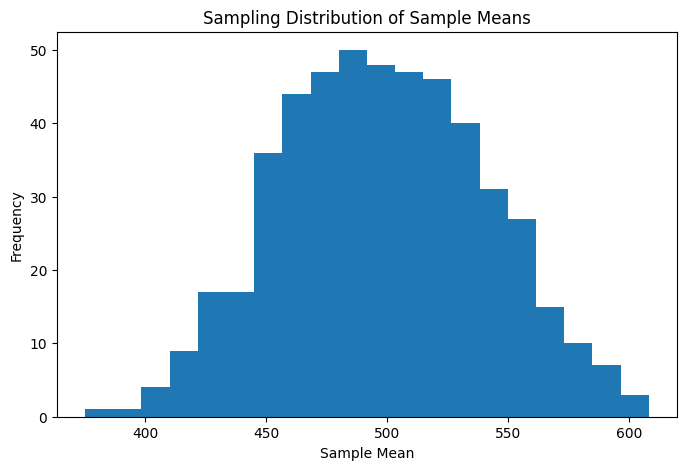

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sample_means,
    bins=20
)

plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

## Code Explanation

The code repeatedly draws bootstrap samples from the population and calculates the mean of each sample.

The collection of sample means forms a sampling distribution.

This demonstrates that although individual samples vary, the average of sample means tends to converge toward the population mean.

Sampling distributions are central to statistical inference and machine learning evaluation.

## Theory: Bootstrap Method

Bootstrap is a resampling technique used to estimate uncertainty in statistical estimates.

The method works by:

1. Drawing samples with replacement.
2. Computing a statistic for each sample.
3. Repeating the process many times.
4. Analyzing the resulting distribution.

Bootstrap methods are particularly useful when:

- Population parameters are unknown.
- Sample sizes are small.
- Analytical solutions are difficult to obtain.

Bootstrap provides a practical way to estimate variability and confidence intervals.

In [4]:
bootstrap_means = []

for i in range(1000):
    bootstrap_sample = sample.sample(
        frac=1,
        replace=True
    )
    
    bootstrap_means.append(
        bootstrap_sample.mean()
    )

bootstrap_means = pd.Series(
    bootstrap_means
)

print("Bootstrap Mean:")
print(bootstrap_means.mean())

Bootstrap Mean:
473.25890000000004


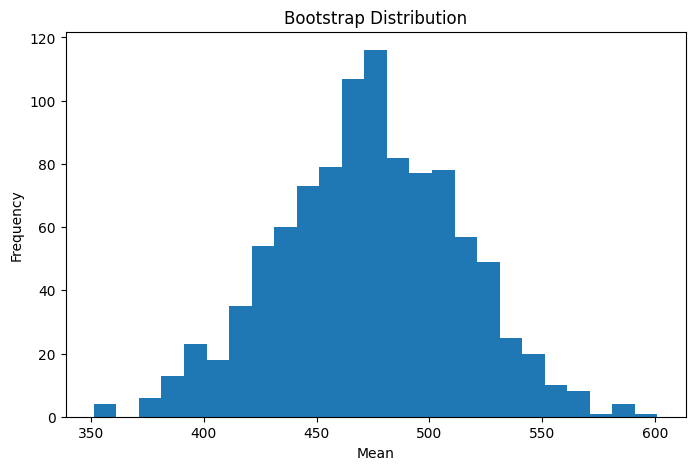

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    bootstrap_means,
    bins=25
)

plt.title("Bootstrap Distribution")
plt.xlabel("Mean")
plt.ylabel("Frequency")

plt.show()

## Theory: Confidence Intervals

A confidence interval provides a range of values that is likely to contain the true population parameter.

A 95% confidence interval means that if the sampling process were repeated many times, approximately 95% of the resulting intervals would contain the true parameter.

Confidence intervals provide more information than a single point estimate because they quantify uncertainty.

In [6]:
lower = bootstrap_means.quantile(0.025)
upper = bootstrap_means.quantile(0.975)

print("95% Confidence Interval")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

95% Confidence Interval
Lower Bound: 392.08700000000005
Upper Bound: 549.924


## Discussion

Sampling distributions and bootstrap methods help quantify uncertainty in statistical estimates.

The bootstrap distribution demonstrates how repeated resampling can approximate the variability of a statistic.

Confidence intervals provide a practical way to communicate uncertainty and reliability.

These concepts are widely used in machine learning, A/B testing, predictive modeling, and statistical inference.

## Theory: Probability Distribution

A probability distribution describes how the values of a random variable are distributed.

Probability distributions are fundamental in statistics because they help model uncertainty and randomness.

Common probability distributions include:

- Uniform Distribution
- Normal Distribution
- Binomial Distribution
- Poisson Distribution

Each distribution has unique characteristics and applications.

In [7]:
import numpy as np

uniform_data = np.random.uniform(
    low=0,
    high=1,
    size=1000
)

print("Mean:")
print(uniform_data.mean())

print("\nStandard Deviation:")
print(uniform_data.std())

Mean:
0.4944112130644993

Standard Deviation:
0.2867818666864866


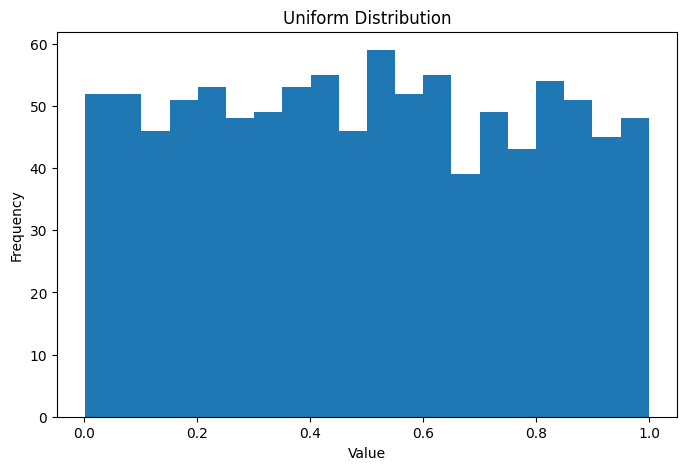

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    uniform_data,
    bins=20
)

plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

## Theory: Normal Distribution

The normal distribution is one of the most important probability distributions in statistics.

Characteristics:

- Bell-shaped curve
- Symmetrical around the mean
- Mean = Median = Mode

Many real-world variables approximately follow a normal distribution, including:

- Heights
- Test scores
- Measurement errors

Normal distributions play a central role in statistical inference and machine learning.

In [9]:
normal_data = np.random.normal(
    loc=50,
    scale=10,
    size=1000
)

print("Mean:")
print(normal_data.mean())

print("\nStandard Deviation:")
print(normal_data.std())

Mean:
50.1036269890877

Standard Deviation:
10.130698253918775


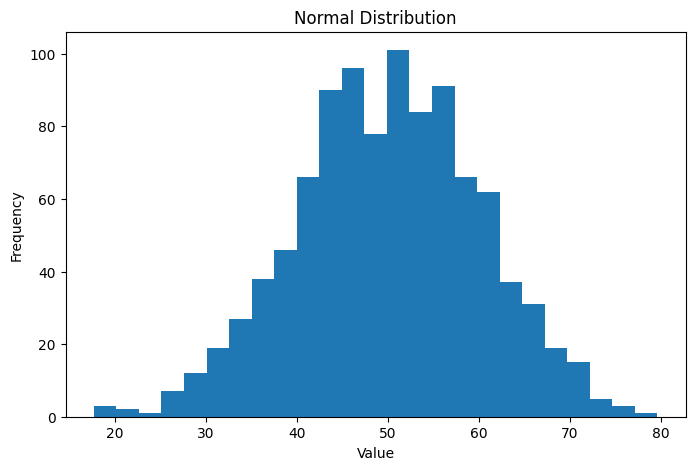

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    normal_data,
    bins=25
)

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

## Theory: Central Limit Theorem (CLT)

The Central Limit Theorem states that the sampling distribution of the sample mean approaches a normal distribution as the sample size increases, regardless of the original population distribution.

Key implications:

- Sample means become normally distributed.
- Larger sample sizes produce more stable estimates.
- Statistical inference becomes possible.

The CLT is one of the most important concepts in statistics because it explains why normal distributions appear frequently in practice.

In [11]:
clt_means = []

for i in range(1000):
    
    sample = np.random.uniform(
        0,
        100,
        50
    )
    
    clt_means.append(
        np.mean(sample)
    )

clt_means = np.array(clt_means)

print("Average Sample Mean:")
print(clt_means.mean())

Average Sample Mean:
49.93748871760583


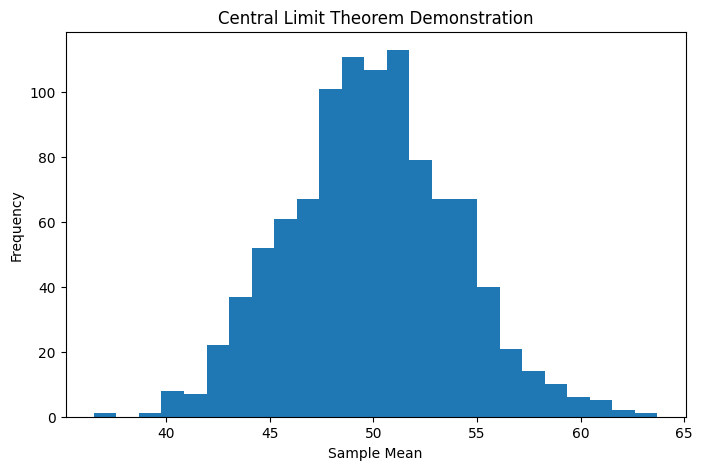

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    clt_means,
    bins=25
)

plt.title("Central Limit Theorem Demonstration")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

## Code Explanation

The simulation repeatedly generates random samples from a uniform distribution and calculates the mean of each sample.

Although the original population follows a uniform distribution, the distribution of sample means gradually approaches a normal distribution.

This demonstrates the Central Limit Theorem and explains why normal distributions frequently appear in statistical analysis and machine learning applications.

## Discussion

Data and sampling distributions provide the foundation for statistical inference and machine learning.

Random sampling allows data scientists to estimate population characteristics using a manageable subset of data. However, different samples may produce different results due to natural variability.

Bootstrap methods help estimate uncertainty by repeatedly resampling data and generating empirical distributions. These techniques are particularly valuable when analytical solutions are difficult to obtain.

Probability distributions describe uncertainty and randomness, while the Central Limit Theorem explains why sampling distributions often become approximately normal.

Together, these concepts enable reliable decision-making and model evaluation in data science projects.

## Key Takeaways

- A population represents the complete set of observations.
- A sample is a subset selected for analysis.
- Random sampling reduces bias and improves representativeness.
- Sampling distributions describe how statistics vary across samples.
- Bootstrap methods estimate uncertainty through resampling.
- Confidence intervals quantify reliability.
- Probability distributions model uncertainty.
- The Central Limit Theorem explains the emergence of normal distributions.

## Real-World Applications

The concepts presented in this chapter are widely used in practical data science applications.

Examples include:

- Market research surveys
- Customer satisfaction analysis
- A/B testing
- Medical studies
- Financial forecasting
- Machine learning model evaluation

Sampling techniques allow organizations to draw conclusions without collecting data from every individual in a population.

## Machine Learning Connection

Sampling plays an essential role in machine learning.

Examples include:

### Train-Test Split

Datasets are divided into training and testing subsets to evaluate model performance.

### Cross Validation

Multiple samples are used to obtain robust performance estimates.

### Bootstrap Aggregation (Bagging)

Ensemble methods such as Random Forest use bootstrap sampling to improve prediction accuracy.

### Model Evaluation

Confidence intervals help quantify uncertainty in performance metrics.

Understanding sampling distributions improves the reliability and interpretability of machine learning systems.

## Advantages of Sampling

Sampling offers several practical benefits:

- Reduces computational cost.
- Saves time and resources.
- Enables faster experimentation.
- Facilitates statistical inference.
- Supports scalable machine learning workflows.

In large-scale datasets, sampling often provides results that are sufficiently accurate while significantly reducing processing requirements.

## Limitations of Sampling

Despite its advantages, sampling has limitations.

Common challenges include:

- Sampling bias
- Small sample sizes
- Non-representative samples
- Measurement errors
- Data collection issues

Careful sampling design is necessary to ensure valid conclusions.

## Best Practices

To obtain reliable results:

1. Use random sampling whenever possible.
2. Ensure sufficient sample size.
3. Check for sampling bias.
4. Use bootstrap methods for uncertainty estimation.
5. Report confidence intervals alongside point estimates.
6. Validate assumptions before applying statistical methods.

## Reflection

This chapter highlights the importance of understanding how data is collected and how uncertainty affects statistical conclusions.

A strong understanding of sampling theory enables data scientists to make more reliable predictions, evaluate models accurately, and communicate results with confidence.

## Conclusion

Data and Sampling Distributions are fundamental concepts in statistics and machine learning.

This chapter introduced random sampling, sampling distributions, bootstrap methods, confidence intervals, probability distributions, and the Central Limit Theorem.

These concepts provide the mathematical foundation for statistical inference, predictive modeling, experimentation, and machine learning evaluation.

A solid understanding of sampling theory helps ensure that conclusions drawn from data are accurate, reliable, and scientifically valid.

## References

Bruce, P., Bruce, A., & Gedeck, P. (2020).

Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python (2nd Edition).

O'Reilly Media.